In [87]:
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, LabelEncoder
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.svm import SVC
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import classification_report, accuracy_score

# # 1. Load Data
# df = pd.read_csv('singer_features.csv')

# # 2. Prepare X and y
# X = df.drop(columns=['label'])
# y = df['label']

# # Encode the singer names into numbers (e.g., 'f1' -> 0, 'm1' -> 1)
# le = LabelEncoder()
# y = le.fit_transform(y)

# # 3. Split data (80% train, 20% test)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # 4. Scale features (CRITICAL for SVM and KNN)
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

# # 5. Define Models
# models = {
#     "Random Forest": RandomForestClassifier(n_estimators=100),
#     "SVM": SVC(kernel='linear'),
#     "KNN": KNeighborsClassifier(n_neighbors=5),
#     "Gradient Boosting": GradientBoostingClassifier()
# }

# # 6. Train and Evaluate
# print(f"{'Model':<20} | {'Accuracy':<10}")
# print("-" * 35)

# for name, model in models.items():
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     acc = accuracy_score(y_test, y_pred)
#     print(f"{name:<20} | {acc:.4f}")
    
#     # Optional: Get detailed report for your review document
#     # print(classification_report(y_test, y_pred))

In [88]:
import pandas as pd

In [89]:
df = pd.read_csv('singer_features.csv')

In [90]:
df.head()

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,spectral_centroid,zcr,chroma_mean,label
0,-360.09933,22.019585,-72.170220,-25.820877,-28.075487,0.684296,13.991911,-6.436762,-18.203794,33.657150,-8.518291,3.718016,7.119060,2254.634880,0.099336,0.265914,female1
1,-424.15010,26.204453,-66.430430,41.559240,3.610721,-60.740990,-20.674871,2.494788,-1.760720,25.456635,-2.758845,0.775470,12.229854,2185.109361,0.107815,0.240413,female1
2,-464.52920,-8.834193,-26.840797,72.715360,2.219018,-42.397076,2.727844,-3.554710,-31.591190,19.704456,-18.277350,6.226011,-2.359181,2543.302266,0.098492,0.254612,female1
3,-434.86215,52.839040,-46.433900,0.334090,-40.795803,-28.138374,24.308582,-16.651693,-17.529920,27.494417,-3.355970,2.927056,9.143897,1816.293715,0.070772,0.227547,female1
4,-493.98175,42.129040,0.854069,16.317635,-28.028332,-19.169281,8.368003,-6.219119,-36.691353,19.811087,-19.013870,2.385262,12.418822,1778.560396,0.048666,0.189960,female1


In [91]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df["label"])
x = df.drop("label",axis = 1)

In [92]:
x.head()

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,spectral_centroid,zcr,chroma_mean
0,-360.09933,22.019585,-72.170220,-25.820877,-28.075487,0.684296,13.991911,-6.436762,-18.203794,33.657150,-8.518291,3.718016,7.119060,2254.634880,0.099336,0.265914
1,-424.15010,26.204453,-66.430430,41.559240,3.610721,-60.740990,-20.674871,2.494788,-1.760720,25.456635,-2.758845,0.775470,12.229854,2185.109361,0.107815,0.240413
2,-464.52920,-8.834193,-26.840797,72.715360,2.219018,-42.397076,2.727844,-3.554710,-31.591190,19.704456,-18.277350,6.226011,-2.359181,2543.302266,0.098492,0.254612
3,-434.86215,52.839040,-46.433900,0.334090,-40.795803,-28.138374,24.308582,-16.651693,-17.529920,27.494417,-3.355970,2.927056,9.143897,1816.293715,0.070772,0.227547
4,-493.98175,42.129040,0.854069,16.317635,-28.028332,-19.169281,8.368003,-6.219119,-36.691353,19.811087,-19.013870,2.385262,12.418822,1778.560396,0.048666,0.189960


In [93]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state = 42,test_size = 0.2)

In [94]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
col_names = x.columns
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train),columns=col_names)
x_test_scaled = pd.DataFrame(scaler.fit_transform(x_test),columns=col_names)

In [95]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(x_train,y_train)

LinearRegression()

In [96]:
y_pred = linear_model.predict(x_test)

In [97]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print("r2_score", r2_score(y_test,y_pred))

r2_score 0.5548229004463391


In [98]:
linear_scaled_model = LinearRegression()
linear_scaled_model.fit(x_train_scaled,y_train)
y_scaled_pred = linear_model.predict(x_test_scaled)
print("r2_score", r2_score(y_test,y_scaled_pred))

r2_score -30.740946308633678


In [99]:
from sklearn.linear_model import LogisticRegression
log_reg_model = LogisticRegression(solver='saga', max_iter=5000, random_state=42)
log_reg_model.fit(x_train,y_train)
y_pred = log_reg_model.predict(x_test)

In [100]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
print('accuracy_score',accuracy_score(y_test,y_pred))
print('precision_score',precision_score(y_test,y_pred,average="macro"))
print('recall_score',recall_score(y_test,y_pred,average = "macro"))
print('f1_score',f1_score(y_test,y_pred,average = "macro"))

accuracy_score 0.6514522821576764
precision_score 0.6577978047768956
recall_score 0.6608529858916536
f1_score 0.6545548474703711


In [101]:
log_scaled_model = LogisticRegression()
log_scaled_model.fit(x_train_scaled,y_train)
y_scaled_pred = log_scaled_model.predict(x_test_scaled)
print('accuracy_score',accuracy_score(y_test,y_scaled_pred))
print('precision_score',precision_score(y_test,y_scaled_pred,average="macro"))
print('recall_score',recall_score(y_test,y_scaled_pred,average = "macro"))
print('f1_score',f1_score(y_test,y_scaled_pred,average = "macro"))

accuracy_score 0.7330567081604425
precision_score 0.7357182136204933
recall_score 0.7365129446668774
f1_score 0.7323141356993061


In [109]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors = 10)
knn_model.fit(x_train,y_train)
y_pred = knn_model.predict(x_test)
print('accuracy_score',accuracy_score(y_test,y_pred))
print('precision_score',precision_score(y_test,y_pred,average="macro"))
print('recall_score',recall_score(y_test,y_pred,average = "macro"))
print('f1_score',f1_score(y_test,y_pred,average = "macro"))

accuracy_score 0.41217150760719223
precision_score 0.43876822841982294
recall_score 0.4202462506116175
f1_score 0.4174519746101937


In [119]:
accuracy = []
for i in range(2,25):
    knn_scaled_model = KNeighborsClassifier(n_neighbors = i)
    knn_scaled_model.fit(x_train_scaled,y_train)
    y_scaled_pred = knn_scaled_model.predict(x_test_scaled)
    accuracy.append(accuracy_score(y_test,y_scaled_pred))
    
#print('accuracy_score',accuracy_score(y_test,y_scaled_pred))
# print('precision_score',precision_score(y_test,y_scaled_pred,average="macro"))
# print('recall_score',recall_score(y_test,y_scaled_pred,average = "macro"))
# print('f1_score',f1_score(y_test,y_scaled_pred,average = "macro"))

<BarContainer object of 23 artists>

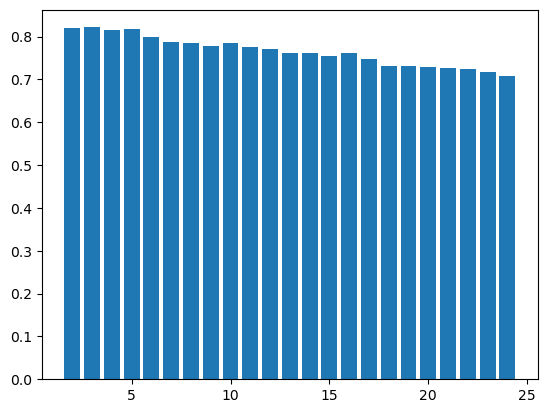

In [120]:
import matplotlib.pyplot as plt
plt.bar(range(2,25),accuracy)

In [105]:
from sklearn.tree import DecisionTreeClassifier
dtc_model = DecisionTreeClassifier()
dtc_model.fit(x_train,y_train)
y_pred = dtc_model.predict(x_test)
print('accuracy_score',accuracy_score(y_test,y_pred))
print('precision_score',precision_score(y_test,y_pred,average="macro"))
print('recall_score',recall_score(y_test,y_pred,average = "macro"))
print('f1_score',f1_score(y_test,y_pred,average = "macro"))

accuracy_score 0.5601659751037344
precision_score 0.564504563876327
recall_score 0.5661583245797768
f1_score 0.5620079560924347


In [110]:
dtc_scaled_model=  DecisionTreeClassifier()
dtc_scaled_model.fit(x_train_scaled,y_train)
y_scaled_pred = dtc_scaled_model.predict(x_test_scaled)
print('accuracy_score',accuracy_score(y_test,y_scaled_pred))
print('precision_score',precision_score(y_test,y_scaled_pred,average="macro"))
print('recall_score',recall_score(y_test,y_scaled_pred,average = "macro"))
print('f1_score',f1_score(y_test,y_scaled_pred,average = "macro"))

accuracy_score 0.5477178423236515
precision_score 0.5530053194825044
recall_score 0.5556423962364989
f1_score 0.5464081573173002
